# Statistics Collection for 3D and 2D Instances in TIFF Masks

This notebook walks through directories, finds mask/masks folders and analyzes TIFF annotation files.

**Enhanced statistics:**
- Volume per cell (3D voxel count)
- Z-extent (number of slices occupied)
- Mean 2D area per slice
- Aspect ratio (Z / sqrt(XY))
- Neurons per slice (per-file normalization)
- Quality control (tiny objects, 1-slice objects)
- Percentiles (p5, p95) for robust statistics

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import tifffile
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
def analyze_mask_file(mask_path):
    """
    Analyzes a single TIFF mask file.

    Returns:
        dict: Statistics about the mask including normalized metrics
    """
    try:
        mask = tifffile.imread(mask_path)

        if mask.ndim == 2:
            unique_labels = np.unique(mask)
            unique_labels = unique_labels[unique_labels > 0]
            n_instances = len(unique_labels)

            return {
                'n_instances_3d': n_instances,
                'n_instances_2d': n_instances,
                'n_slices': 1,
                'cell_stats': []
            }

        elif mask.ndim == 3:
            unique_labels_3d = np.unique(mask)
            unique_labels_3d = unique_labels_3d[unique_labels_3d > 0]
            n_instances_3d = len(unique_labels_3d)

            n_instances_2d = 0
            n_slices = mask.shape[0]
            neurons_per_slice = []

            for z in range(n_slices):
                slice_2d = mask[z]
                unique_labels_2d = np.unique(slice_2d)
                unique_labels_2d = unique_labels_2d[unique_labels_2d > 0]
                n_2d_in_slice = len(unique_labels_2d)
                n_instances_2d += n_2d_in_slice
                neurons_per_slice.append(n_2d_in_slice)

            cell_stats = []
            for label in unique_labels_3d:
                cell_mask = mask == label

                volume = np.sum(cell_mask)

                z_presence = np.any(cell_mask, axis=(1, 2))
                z_extent = np.sum(z_presence)

                areas_per_slice = []
                for z in range(n_slices):
                    if z_presence[z]:
                        area = np.sum(cell_mask[z])
                        areas_per_slice.append(area)

                mean_2d_area = np.mean(areas_per_slice) if areas_per_slice else 0

                xy_characteristic_length = np.sqrt(mean_2d_area) if mean_2d_area > 0 else 1
                aspect_ratio = z_extent / xy_characteristic_length if xy_characteristic_length > 0 else 0

                # ✅ ДОБАВЬ ЭТИ СТРОКИ:
                z_extent_normalized = z_extent / n_slices
                volume_per_slice = volume / n_slices

                cell_stats.append({
                    'label': int(label),
                    'volume': int(volume),
                    'z_extent': int(z_extent),
                    'mean_2d_area': float(mean_2d_area),
                    'aspect_ratio': float(aspect_ratio),
                    'stack_depth': int(n_slices),  # ✅ И ЭТО
                    'z_extent_normalized': float(z_extent_normalized),  # ✅ И ЭТО
                    'volume_per_slice': float(volume_per_slice)  # ✅ И ЭТО
                })

            return {
                'n_instances_3d': n_instances_3d,
                'n_instances_2d': n_instances_2d,
                'n_slices': n_slices,
                'neurons_per_slice': neurons_per_slice,
                'cell_stats': cell_stats
            }

        else:
            print(f"  Warning: unexpected dimensionality {mask.ndim} in {mask_path}")
            return {
                'n_instances_3d': 0,
                'n_instances_2d': 0,
                'n_slices': 0,
                'cell_stats': []
            }

    except Exception as e:
        print(f"  Error reading {mask_path}: {e}")
        return {
            'n_instances_3d': 0,
            'n_instances_2d': 0,
            'n_slices': 0,
            'cell_stats': []
        }

In [3]:
def collect_statistics(root_dir, allowed_subfolders, z_step_um=1.0, pixel_size_um=None,
                       volume_threshold=100):
    """
    Collects statistics across masks only from explicitly allowed subfolders.

    Args:
        root_dir: root directory for search
        allowed_subfolders: list of relative subfolders inside root_dir to process only
                            Example: ['masks'] or ['annotator_1/masks', 'annotator_2/masks']
        z_step_um: z-step in micrometers
        pixel_size_um: XY pixel size in micrometers (optional)
        volume_threshold: minimum volume in voxels to not be considered 'tiny'

    Returns:
        dict: Complete statistics for visualization
    """
    root_path = Path(root_dir)

    if not root_path.exists():
        print(f"Error: directory {root_dir} does not exist")
        return None

    if not allowed_subfolders:
        print("Error: allowed_subfolders must be explicitly provided")
        return None

    folder_stats = defaultdict(lambda: {
        'files': [],
        'total_3d': 0,
        'total_2d': 0,
        'total_slices': 0,
        'all_cell_stats': [],
        'slices_per_file': [],
        'neurons_per_file': [],
        'neurons_per_slice_per_file': []
    })

    print(f"Searching only in explicitly allowed folders under {root_dir}...\n")

    mask_dirs_to_process = []

    for subfolder in allowed_subfolders:
        mask_dir = (root_path / subfolder).resolve()

        try:
            mask_dir.relative_to(root_path.resolve())
        except ValueError:
            print(f"Skipping invalid folder outside root_dir: {mask_dir}")
            continue

        if not mask_dir.exists():
            print(f"Skipping missing folder: {mask_dir}")
            continue

        if not mask_dir.is_dir():
            print(f"Skipping non-directory path: {mask_dir}")
            continue

        mask_dirs_to_process.append(mask_dir)

    if not mask_dirs_to_process:
        print("No allowed folders found")
        return None

    for mask_dir in sorted(set(mask_dirs_to_process)):
        print(f"Processing folder: {mask_dir}")

        tiff_files = sorted(list(mask_dir.glob("*.tif")) + list(mask_dir.glob("*.tiff")))

        if not tiff_files:
            print("  No TIFF files\n")
            continue

        print(f"  Found {len(tiff_files)} TIFF files")

        folder_key = str(mask_dir.relative_to(root_path))

        for tiff_file in tiff_files:
            result = analyze_mask_file(tiff_file)

            if result['n_instances_3d'] > 0 or result['n_instances_2d'] > 0:
                folder_stats[folder_key]['files'].append({
                    'name': tiff_file.name,
                    '3d': result['n_instances_3d'],
                    '2d': result['n_instances_2d'],
                    'slices': result['n_slices'],
                    'neurons_per_slice': result.get('neurons_per_slice', [])
                })
                folder_stats[folder_key]['total_3d'] += result['n_instances_3d']
                folder_stats[folder_key]['total_2d'] += result['n_instances_2d']
                folder_stats[folder_key]['total_slices'] += result['n_slices']
                folder_stats[folder_key]['all_cell_stats'].extend(result['cell_stats'])

                folder_stats[folder_key]['slices_per_file'].append(result['n_slices'])
                folder_stats[folder_key]['neurons_per_file'].append(result['n_instances_3d'])

                if result['n_slices'] > 0:
                    nps = result['n_instances_3d'] / result['n_slices']
                    folder_stats[folder_key]['neurons_per_slice_per_file'].append(nps)

        print()

    if not folder_stats:
        print("No TIFF files with valid masks found")
        return None

    print("\n" + "=" * 80)
    print("STATISTICS PER FOLDER")
    print("=" * 80 + "\n")

    total_all_3d = 0
    total_all_2d = 0
    total_all_files = 0
    all_cell_stats_combined = []

    for folder_path in sorted(folder_stats.keys()):
        stats = folder_stats[folder_path]
        n_files = len(stats['files'])

        if n_files == 0:
            continue

        total_all_3d += stats['total_3d']
        total_all_2d += stats['total_2d']
        total_all_files += n_files
        all_cell_stats_combined.extend(stats['all_cell_stats'])

        print(f"Folder: {folder_path}")
        print(f"  Files: {n_files}")
        print(f"  3D instances: {stats['total_3d']}")
        print(f"  2D instances: {stats['total_2d']}")
        print(f"  Total slices: {stats['total_slices']}")

        print(f"\n  Stack depth / normalization:")
        slices_per_file = stats['slices_per_file']
        print(f"    Slices per file: mean={np.mean(slices_per_file):.1f}, "
              f"median={np.median(slices_per_file):.1f}, "
              f"min={np.min(slices_per_file)}, "
              f"max={np.max(slices_per_file)}")

        stack_depths = [s * z_step_um for s in slices_per_file]
        print(f"    Stack depth (µm): mean={np.mean(stack_depths):.1f}, "
              f"median={np.median(stack_depths):.1f}, "
              f"min={np.min(stack_depths):.1f}, "
              f"max={np.max(stack_depths):.1f}")

        nps_per_file = stats['neurons_per_slice_per_file']
        print(f"    Neurons per slice (per-file): mean={np.mean(nps_per_file):.2f}, "
              f"median={np.median(nps_per_file):.2f}, "
              f"std={np.std(nps_per_file):.2f}, "
              f"min={np.min(nps_per_file):.2f}, "
              f"max={np.max(nps_per_file):.2f}")
        print(f"      Note: apparent yield per slice, not density")

        if stats['all_cell_stats']:
            volumes = np.array([c['volume'] for c in stats['all_cell_stats']])
            z_extents = np.array([c['z_extent'] for c in stats['all_cell_stats']])
            mean_2d_areas = np.array([c['mean_2d_area'] for c in stats['all_cell_stats']])
            aspect_ratios = np.array([c['aspect_ratio'] for c in stats['all_cell_stats']])
            z_extents_norm = np.array([c['z_extent_normalized'] for c in stats['all_cell_stats']])
            volumes_per_slice = np.array([c['volume_per_slice'] for c in stats['all_cell_stats']])

            tiny_objects = np.sum(volumes < volume_threshold)
            one_slice_objects = np.sum(z_extents == 1)

            print(f"\n  Quality control:")
            print(f"    Tiny objects (volume < {volume_threshold}): "
                  f"{tiny_objects} ({100 * tiny_objects / len(volumes):.1f}%)")
            print(f"    1-slice objects: "
                  f"{one_slice_objects} ({100 * one_slice_objects / len(z_extents):.1f}%)")

            print(f"\n  Per-cell statistics (n={len(stats['all_cell_stats'])}):")

            print(f"    Volume (voxels):")
            print(f"      mean={np.mean(volumes):.1f}, median={np.median(volumes):.1f}, "
                  f"std={np.std(volumes):.1f}")
            print(f"      p5={np.percentile(volumes, 5):.1f}, "
                  f"p95={np.percentile(volumes, 95):.1f}")

            print(f"    Z-extent (slices):")
            print(f"      mean={np.mean(z_extents):.1f}, median={np.median(z_extents):.1f}, "
                  f"std={np.std(z_extents):.1f}")
            print(f"      p5={np.percentile(z_extents, 5):.1f}, "
                  f"p95={np.percentile(z_extents, 95):.1f}")

            print(f"    Z-extent normalized (fraction of stack):")
            print(f"      mean={np.mean(z_extents_norm):.3f}, median={np.median(z_extents_norm):.3f}, "
                  f"std={np.std(z_extents_norm):.3f}")
            print(f"      p5={np.percentile(z_extents_norm, 5):.3f}, "
                  f"p95={np.percentile(z_extents_norm, 95):.3f}")

            print(f"    Volume per slice (voxels/slice):")
            print(f"      mean={np.mean(volumes_per_slice):.1f}, median={np.median(volumes_per_slice):.1f}, "
                  f"std={np.std(volumes_per_slice):.1f}")
            print(f"      p5={np.percentile(volumes_per_slice, 5):.1f}, "
                  f"p95={np.percentile(volumes_per_slice, 95):.1f}")

            print(f"    Mean 2D area (pixels):")
            print(f"      mean={np.mean(mean_2d_areas):.1f}, median={np.median(mean_2d_areas):.1f}, "
                  f"std={np.std(mean_2d_areas):.1f}")
            print(f"      p5={np.percentile(mean_2d_areas, 5):.1f}, "
                  f"p95={np.percentile(mean_2d_areas, 95):.1f}")

            print(f"    Aspect ratio (Z / sqrt(mean_XY_area)):")
            print(f"      mean={np.mean(aspect_ratios):.3f}, median={np.median(aspect_ratios):.3f}, "
                  f"std={np.std(aspect_ratios):.3f}")
            print(f"      p5={np.percentile(aspect_ratios, 5):.3f}, "
                  f"p95={np.percentile(aspect_ratios, 95):.3f}")

        print()

    print("=" * 80)
    print("OVERALL STATISTICS")
    print("=" * 80)
    print(f"Total files: {total_all_files}")
    print(f"Total 3D instances: {total_all_3d}")
    print(f"Total 2D instances: {total_all_2d}")
    if total_all_files > 0:
        print(f"Average 3D per file: {total_all_3d / total_all_files:.1f}")
        print(f"Average 2D per file: {total_all_2d / total_all_files:.1f}")
    if total_all_3d > 0:
        print(f"2D/3D ratio: {total_all_2d / total_all_3d:.2f}")

    return folder_stats

## Run Analysis

Specify the path to the root directory with your data:

In [4]:
# Specify the path to your directory
root_directory = "/NAS/mmaiurov/datasets_benchmark"

# Configuration
z_step_um = 1.0  # Z-step in micrometers
pixel_size_um_dodt = 0.115
pixel_size_um_oblique = None # XY pixel size in micrometers (optional, for density)
volume_threshold = 100  # Minimum voxels to not be 'tiny'

# By default searches for 'mask' and 'masks' folders
# You can specify custom folder names:
mask_folder_names = ['masks', 'Viktor`s masks checked', 'Mariachiara`s masks','Viktor`s masks fluo', 'Viktor`s masks']
stats_data = {}

datasets = [
    ("rat_neurons_dodt", "/NAS/mmaiurov/datasets_benchmark/rat_neurons_dodt"),
    ("rat_neurons_oblique", "/NAS/mmaiurov/datasets_benchmark/rat_neurons_oblique"),
    ("mice_neurons_dodt", "/NAS/mmaiurov/datasets_benchmark/mice_neurons_dodt"),
    ("mice_neurons_oblique", "/NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique"),
    ("human_neurons_dodt", "/NAS/mmaiurov/datasets_benchmark/human_neurons_dodt"),
    ("human_neurons_oblique", "/NAS/mmaiurov/datasets_benchmark/human_neurons_oblique"),
]

for dataset_name, root_dir in datasets:
    folder_stats = collect_statistics(
        root_dir,
        allowed_subfolders=["masks", "Viktor`s masks checked", "Mariachiara`s masks"]
    )

    if folder_stats:
        for folder_path, data in folder_stats.items():
            stats_data[f"{dataset_name}/{folder_path}"] = data


Searching only in explicitly allowed folders under /NAS/mmaiurov/datasets_benchmark/rat_neurons_dodt...

Skipping missing folder: /NAS/mmaiurov/datasets_benchmark/rat_neurons_dodt/Viktor`s masks checked
Skipping missing folder: /NAS/mmaiurov/datasets_benchmark/rat_neurons_dodt/Mariachiara`s masks
Processing folder: /NAS/mmaiurov/datasets_benchmark/rat_neurons_dodt/masks
  Found 40 TIFF files


STATISTICS PER FOLDER

Folder: masks
  Files: 40
  3D instances: 1249
  2D instances: 14584
  Total slices: 2560

  Stack depth / normalization:
    Slices per file: mean=64.0, median=64.0, min=64, max=64
    Stack depth (µm): mean=64.0, median=64.0, min=64.0, max=64.0
    Neurons per slice (per-file): mean=0.49, median=0.48, std=0.13, min=0.17, max=0.78
      Note: apparent yield per slice, not density

  Quality control:
    Tiny objects (volume < 100): 0 (0.0%)
    1-slice objects: 1 (0.1%)

  Per-cell statistics (n=1249):
    Volume (voxels):
      mean=123829.2, median=110888.0, std=76054.9


ddd## Visualization

In [5]:
## Statistical Analysis with ANCOVA
def run_ancova_analysis(oblique_cells, dodt_cells, oblique_stack_depth, dodt_stack_depth, metric):
    """
    Run ANCOVA with stack depth as covariate.

    Args:
        oblique_cells: list of cell stats from oblique mode
        dodt_cells: list of cell stats from dodt mode
        oblique_stack_depth: typical stack depth for oblique
        dodt_stack_depth: typical stack depth for dodt
        metric: which metric to analyze ('z_extent', 'volume', etc.)

    Returns:
        dict with ANCOVA results
    """
    # Prepare dataframe
    data = []

    for cell in oblique_cells:
        data.append({
            'value': cell[metric],
            'mode': 'Oblique',
            'stack_depth': cell.get('stack_depth', oblique_stack_depth)
        })

    for cell in dodt_cells:
        data.append({
            'value': cell[metric],
            'mode': 'DODT',
            'stack_depth': cell.get('stack_depth', dodt_stack_depth)
        })

    df = pd.DataFrame(data)

    # Remove outliers (optional, based on IQR)
    Q1 = df['value'].quantile(0.25)
    Q3 = df['value'].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df[(df['value'] >= Q1 - 1.5*IQR) & (df['value'] <= Q3 + 1.5*IQR)]

    # Run ANCOVA: value ~ mode + stack_depth
    try:
        model = ols('value ~ C(mode) + stack_depth', data=df_clean).fit()
        anova_results = anova_lm(model, typ=2)

        # Extract key results
        mode_p = anova_results.loc['C(mode)', 'PR(>F)']
        covariate_p = anova_results.loc['stack_depth', 'PR(>F)']

        # Effect size (adjusted means)
        oblique_mean = df_clean[df_clean['mode'] == 'Oblique']['value'].mean()
        dodt_mean = df_clean[df_clean['mode'] == 'DODT']['value'].mean()

        return {
            'model': model,
            'anova': anova_results,
            'mode_p': mode_p,
            'covariate_p': covariate_p,
            'oblique_mean': oblique_mean,
            'dodt_mean': dodt_mean,
            'n_samples': len(df_clean),
            'n_removed': len(df) - len(df_clean)
        }
    except Exception as e:
        print(f"ANCOVA failed for {metric}: {e}")
        return None

In [ ]:
def create_publication_figures(stats_data, save_prefix='figure', alpha=0.05):
    """
    Creates publication-ready figures with ANCOVA analysis.
    Compares oblique vs DODT for each animal type (rats, mice, human).
    Works even when only one acquisition mode is available.
    """
    if stats_data is None:
        print("No data to visualize")
        return

    # Organize data by animal type and acquisition mode
    animal_types = ['rat', 'mice', 'human']

    organized_data = {}
    for animal in animal_types:
        organized_data[animal] = {
            'oblique': {'cells': [], 'nps': [], 'stack_depth': None},
            'dodt': {'cells': [], 'nps': [], 'stack_depth': None}
        }

    # Fill data
    for folder in stats_data.keys():
        folder_lower = folder.lower()

        animal = None
        if 'rat' in folder_lower:
            animal = 'rat'
        elif 'mice' in folder_lower or 'mouse' in folder_lower:
            animal = 'mice'
        elif 'human' in folder_lower:
            animal = 'human'
        else:
            continue

        mode = 'oblique' if 'oblique' in folder_lower else 'dodt'

        organized_data[animal][mode]['cells'].extend(stats_data[folder]['all_cell_stats'])
        organized_data[animal][mode]['nps'].extend(stats_data[folder]['neurons_per_slice_per_file'])

        # Store typical stack depth
        if stats_data[folder]['all_cell_stats']:
            organized_data[animal][mode]['stack_depth'] = stats_data[folder]['all_cell_stats'][0]['stack_depth']

    # Helper function for significance
    def get_significance_stars(p_value):
        if p_value < 0.001:
            return '***'
        elif p_value < 0.01:
            return '**'
        elif p_value < 0.05:
            return '*'
        else:
            return 'ns'

    # Create figure: 3 rows × 5 columns
    fig, axes = plt.subplots(3, 5, figsize=(22, 13))

    colors = {'oblique': 'lightblue', 'dodt': 'lightcoral'}

    # Store statistical results
    statistical_results = {}

    for row, animal in enumerate(animal_types):
        oblique_data = organized_data[animal]['oblique']
        dodt_data = organized_data[animal]['dodt']

        statistical_results[animal] = {}

        # Check if we have ANY data for this animal
        if not oblique_data['cells'] and not dodt_data['cells']:
            for col in range(5):
                axes[row, col].text(0.5, 0.5, f'No data for {animal}',
                                   ha='center', va='center', fontsize=12)
                axes[row, col].set_xticks([])
                axes[row, col].set_yticks([])
            continue

        # Determine what data we have
        has_oblique = len(oblique_data['cells']) > 0
        has_dodt = len(dodt_data['cells']) > 0
        has_both = has_oblique and has_dodt

        # Column 0: Neurons per slice
        ax = axes[row, 0]
        oblique_nps = oblique_data['nps']
        dodt_nps = dodt_data['nps']

        if oblique_nps or dodt_nps:
            data_to_plot = []
            positions = []
            labels = []
            plot_colors = []
            pos = 1

            if oblique_nps:
                data_to_plot.append(oblique_nps)
                positions.append(pos)
                labels.append('Oblique')
                plot_colors.append(colors['oblique'])
                pos += 1

            if dodt_nps:
                data_to_plot.append(dodt_nps)
                positions.append(pos)
                labels.append('DODT')
                plot_colors.append(colors['dodt'])

            bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                           showmeans=True, meanline=True, meanprops=dict(color='red', linewidth=2))

            for patch, color in zip(bp['boxes'], plot_colors):
                patch.set_facecolor(color)

            ax.set_xticks(positions)
            ax.set_xticklabels(labels, fontsize=11)
            ax.set_ylabel('Neurons per slice', fontsize=11)
            ax.grid(axis='y', alpha=0.3)

            # Add n= annotations
            for i, (data, pos) in enumerate(zip(data_to_plot, positions)):
                y_min = ax.get_ylim()[0]
                y_range = ax.get_ylim()[1] - y_min
                ax.text(pos, y_min + 0.02 * y_range, f'n={len(data)}',
                       ha='center', va='bottom', fontsize=9, style='italic')

            # Statistical test only if both present
            if has_both and oblique_nps and dodt_nps:
                stat, p_value = stats.mannwhitneyu(oblique_nps, dodt_nps, alternative='two-sided')
                statistical_results[animal]['nps'] = {'test': 'Mann-Whitney U', 'p_value': p_value}

                y_max = max(max(oblique_nps), max(dodt_nps))
                y_range = y_max - min(min(oblique_nps), min(dodt_nps))
                y_sig = y_max + 0.15 * y_range
                ax.plot([positions[0], positions[-1]], [y_sig, y_sig], 'k-', linewidth=1.5)
                ax.text(np.mean(positions), y_sig, get_significance_stars(p_value),
                       ha='center', va='bottom', fontsize=12, fontweight='bold')

        # Column 1: Z-extent normalized
        ax = axes[row, 1]
        oblique_z_norm = [c['z_extent_normalized'] for c in oblique_data['cells']]
        dodt_z_norm = [c['z_extent_normalized'] for c in dodt_data['cells']]

        if oblique_z_norm or dodt_z_norm:
            data_to_plot = []
            positions = []
            plot_colors = []
            labels = []
            pos = 1

            if oblique_z_norm:
                data_to_plot.append(oblique_z_norm)
                positions.append(pos)
                plot_colors.append(colors['oblique'])
                labels.append('Oblique')
                pos += 1

            if dodt_z_norm:
                data_to_plot.append(dodt_z_norm)
                positions.append(pos)
                plot_colors.append(colors['dodt'])
                labels.append('DODT')

            parts = ax.violinplot(data_to_plot, positions=positions, widths=0.7,
                                 showmeans=True, showmedians=True)

            for pc, color in zip(parts['bodies'], plot_colors):
                pc.set_facecolor(color)
                pc.set_alpha(0.7)

            ax.set_xticks(positions)
            ax.set_xticklabels(labels, fontsize=11)
            ax.set_ylabel('Z-extent\n(fraction of stack)', fontsize=11)
            ax.grid(axis='y', alpha=0.3)

            # Statistical test only if both present
            if has_both and oblique_z_norm and dodt_z_norm:
                stat, p_value = stats.mannwhitneyu(oblique_z_norm, dodt_z_norm, alternative='two-sided')
                statistical_results[animal]['z_extent_norm'] = {'test': 'Mann-Whitney U', 'p_value': p_value}

                y_max = max(max(oblique_z_norm), max(dodt_z_norm))
                y_range = y_max - min(min(oblique_z_norm), min(dodt_z_norm))
                y_sig = y_max + 0.15 * y_range
                ax.plot([positions[0], positions[-1]], [y_sig, y_sig], 'k-', linewidth=1.5)
                ax.text(np.mean(positions), y_sig, get_significance_stars(p_value),
                       ha='center', va='bottom', fontsize=12, fontweight='bold')

        # Column 2: Z-extent absolute (with ANCOVA if both present)
        ax = axes[row, 2]
        oblique_z = [c['z_extent'] for c in oblique_data['cells']]
        dodt_z = [c['z_extent'] for c in dodt_data['cells']]

        if oblique_z or dodt_z:
            data_to_plot = []
            positions = []
            plot_colors = []
            labels = []
            pos = 1

            if oblique_z:
                data_to_plot.append(oblique_z)
                positions.append(pos)
                plot_colors.append(colors['oblique'])
                labels.append('Oblique')
                pos += 1

            if dodt_z:
                data_to_plot.append(dodt_z)
                positions.append(pos)
                plot_colors.append(colors['dodt'])
                labels.append('DODT')

            parts = ax.violinplot(data_to_plot, positions=positions, widths=0.7,
                                 showmeans=True, showmedians=True)

            for pc, color in zip(parts['bodies'], plot_colors):
                pc.set_facecolor(color)
                pc.set_alpha(0.7)

            ax.set_xticks(positions)
            ax.set_xticklabels(labels, fontsize=11)
            ax.set_ylabel('Z-extent (slices)\n[raw, with depth bias]', fontsize=10)
            ax.grid(axis='y', alpha=0.3)

            # ANCOVA only if both present
            if has_both and oblique_z and dodt_z:
                ancova_result = run_ancova_analysis(
                    oblique_data['cells'], dodt_data['cells'],
                    oblique_data['stack_depth'], dodt_data['stack_depth'],
                    'z_extent'
                )

                if ancova_result:
                    p_value = ancova_result['mode_p']
                    statistical_results[animal]['z_extent_ancova'] = {
                        'test': 'ANCOVA',
                        'p_value': p_value,
                        'covariate_p': ancova_result['covariate_p']
                    }

                    y_max = max(max(oblique_z), max(dodt_z))
                    y_range = y_max - min(min(oblique_z), min(dodt_z))
                    y_sig = y_max + 0.15 * y_range
                    ax.plot([positions[0], positions[-1]], [y_sig, y_sig], 'k-', linewidth=1.5)
                    sig_text = f"{get_significance_stars(p_value)}\n(ANCOVA)"
                    ax.text(np.mean(positions), y_sig, sig_text, ha='center', va='bottom',
                           fontsize=10, fontweight='bold')
            else:
                # Add note if only one mode
                ax.text(0.5, 0.98, '[single mode]', transform=ax.transAxes,
                       ha='center', va='top', fontsize=9, style='italic', color='gray')

        # Column 3: Volume per slice
        ax = axes[row, 3]
        oblique_vol_ps = [c['volume_per_slice'] for c in oblique_data['cells']]
        dodt_vol_ps = [c['volume_per_slice'] for c in dodt_data['cells']]

        if oblique_vol_ps or dodt_vol_ps:
            data_to_plot = []
            positions = []
            plot_colors = []
            labels = []
            pos = 1

            if oblique_vol_ps:
                data_to_plot.append(oblique_vol_ps)
                positions.append(pos)
                plot_colors.append(colors['oblique'])
                labels.append('Oblique')
                pos += 1

            if dodt_vol_ps:
                data_to_plot.append(dodt_vol_ps)
                positions.append(pos)
                plot_colors.append(colors['dodt'])
                labels.append('DODT')

            parts = ax.violinplot(data_to_plot, positions=positions, widths=0.7,
                                 showmeans=True, showmedians=True)

            for pc, color in zip(parts['bodies'], plot_colors):
                pc.set_facecolor(color)
                pc.set_alpha(0.7)

            ax.set_xticks(positions)
            ax.set_xticklabels(labels, fontsize=11)
            ax.set_ylabel('Volume per slice\n(voxels/slice)', fontsize=11)
            ax.set_yscale('log')
            ax.grid(axis='y', alpha=0.3, which='both')

            # Statistical test only if both present
            if has_both and oblique_vol_ps and dodt_vol_ps:
                stat, p_value = stats.mannwhitneyu(oblique_vol_ps, dodt_vol_ps, alternative='two-sided')
                statistical_results[animal]['volume_per_slice'] = {'test': 'Mann-Whitney U', 'p_value': p_value}

                y_max = max(max(oblique_vol_ps), max(dodt_vol_ps))
                y_min = min(min(oblique_vol_ps), min(dodt_vol_ps))
                y_sig = y_max * 2
                ax.plot([positions[0], positions[-1]], [y_sig, y_sig], 'k-', linewidth=1.5)
                ax.text(np.mean(positions), y_sig, get_significance_stars(p_value),
                       ha='center', va='bottom', fontsize=12, fontweight='bold')

        # Column 4: Aspect ratio
        ax = axes[row, 4]
        oblique_ar = [c['aspect_ratio'] for c in oblique_data['cells']]
        dodt_ar = [c['aspect_ratio'] for c in dodt_data['cells']]

        if oblique_ar or dodt_ar:
            data_to_plot = []
            positions = []
            plot_colors = []
            labels = []
            pos = 1

            if oblique_ar:
                data_to_plot.append(oblique_ar)
                positions.append(pos)
                plot_colors.append(colors['oblique'])
                labels.append('Oblique')
                pos += 1

            if dodt_ar:
                data_to_plot.append(dodt_ar)
                positions.append(pos)
                plot_colors.append(colors['dodt'])
                labels.append('DODT')

            bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                           showmeans=True, meanline=True, meanprops=dict(color='red', linewidth=2))

            for patch, color in zip(bp['boxes'], plot_colors):
                patch.set_facecolor(color)

            ax.set_xticks(positions)
            ax.set_xticklabels(labels, fontsize=11)
            ax.set_ylabel('Aspect ratio (Z/√XY)', fontsize=11)
            ax.grid(axis='y', alpha=0.3)

            # Statistical test only if both present
            if has_both and oblique_ar and dodt_ar:
                stat, p_value = stats.mannwhitneyu(oblique_ar, dodt_ar, alternative='two-sided')
                statistical_results[animal]['aspect_ratio'] = {'test': 'Mann-Whitney U', 'p_value': p_value}

                y_max = max(max(oblique_ar), max(dodt_ar))
                y_range = y_max - min(min(oblique_ar), min(dodt_ar))
                y_sig = y_max + 0.15 * y_range
                ax.plot([positions[0], positions[-1]], [y_sig, y_sig], 'k-', linewidth=1.5)
                ax.text(np.mean(positions), y_sig, get_significance_stars(p_value),
                       ha='center', va='bottom', fontsize=12, fontweight='bold')

        # Row title
        axes[row, 0].text(-0.3, 0.5, animal.capitalize(),
                         transform=axes[row, 0].transAxes,
                         fontsize=14, fontweight='bold', va='center', rotation=90)

    # Column titles
    col_titles = [
        'A) Annotation yield',
        'B) Z-extent (normalized)',
        'C) Z-extent (raw)',
        'D) Volume density',
        'E) Shape anisotropy'
    ]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=10)

    plt.tight_layout()
    plt.subplots_adjust(left=0.08, wspace=0.3, hspace=0.3)

    plt.savefig(f'{save_prefix}_comparison_ancova.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{save_prefix}_comparison_ancova.pdf', bbox_inches='tight')

    print(f"\nFigures saved:")
    print(f"  - {save_prefix}_comparison_ancova.png")
    print(f"  - {save_prefix}_comparison_ancova.pdf")

    plt.show()

    # Print detailed statistical summary
    print("\n" + "="*80)
    print("STATISTICAL SUMMARY WITH ANCOVA")
    print("="*80)
    print("\nSignificance: * p<0.05, ** p<0.01, *** p<0.001, ns = not significant")
    print("\nTests used:")
    print("  - Mann-Whitney U: for normalized metrics (neurons/slice, z-extent norm, volume/slice)")
    print("  - ANCOVA: for raw metrics with stack depth as covariate (z-extent raw)")
    print("  - Statistical tests only run when BOTH oblique and DODT data available")
    print()

    for animal in animal_types:
        oblique_data = organized_data[animal]['oblique']
        dodt_data = organized_data[animal]['dodt']

        has_oblique = len(oblique_data['cells']) > 0
        has_dodt = len(dodt_data['cells']) > 0
        has_both = has_oblique and has_dodt

        if not has_oblique and not has_dodt:
            continue

        print(f"\n{animal.upper()}:")
        print("-" * 70)

        # Show which modes are available
        status = []
        if has_oblique:
            status.append(f"Oblique (depth={oblique_data['stack_depth']})")
        if has_dodt:
            status.append(f"DODT (depth={dodt_data['stack_depth']})")
        print(f"Available: {', '.join(status)}")

        if not has_both:
            print("⚠️  Only one acquisition mode available - no statistical comparison possible")
        print()

        # Neurons per slice
        if oblique_data['nps'] or dodt_data['nps']:
            print(f"Neurons per slice (per-file):")
            if oblique_data['nps']:
                oblique_nps = oblique_data['nps']
                print(f"  Oblique: {np.mean(oblique_nps):.3f} ± {np.std(oblique_nps):.3f} "
                      f"(median: {np.median(oblique_nps):.3f}, n={len(oblique_nps)} files)")
            if dodt_data['nps']:
                dodt_nps = dodt_data['nps']
                print(f"  DODT:    {np.mean(dodt_nps):.3f} ± {np.std(dodt_nps):.3f} "
                      f"(median: {np.median(dodt_nps):.3f}, n={len(dodt_nps)} files)")

            if has_both and 'nps' in statistical_results[animal]:
                p_val = statistical_results[animal]['nps']['p_value']
                print(f"  → {statistical_results[animal]['nps']['test']}: p = {p_val:.4e} {get_significance_stars(p_val)}")
                fold = np.mean(oblique_nps) / np.mean(dodt_nps) if np.mean(dodt_nps) > 0 else float('inf')
                print(f"  → Fold change (Oblique/DODT): {fold:.2f}×")

        # Z-extent normalized
        oblique_z_norm = [c['z_extent_normalized'] for c in oblique_data['cells']]
        dodt_z_norm = [c['z_extent_normalized'] for c in dodt_data['cells']]

        if oblique_z_norm or dodt_z_norm:
            print(f"\nZ-extent normalized (fraction of stack):")
            if oblique_z_norm:
                print(f"  Oblique: {np.mean(oblique_z_norm):.3f} ± {np.std(oblique_z_norm):.3f} "
                      f"(median: {np.median(oblique_z_norm):.3f}, n={len(oblique_z_norm)} cells)")
            if dodt_z_norm:
                print(f"  DODT:    {np.mean(dodt_z_norm):.3f} ± {np.std(dodt_z_norm):.3f} "
                      f"(median: {np.median(dodt_z_norm):.3f}, n={len(dodt_z_norm)} cells)")

            if has_both and 'z_extent_norm' in statistical_results[animal]:
                p_val = statistical_results[animal]['z_extent_norm']['p_value']
                print(f"  → {statistical_results[animal]['z_extent_norm']['test']}: p = {p_val:.4e} {get_significance_stars(p_val)}")

        # Z-extent raw with ANCOVA
        oblique_z = [c['z_extent'] for c in oblique_data['cells']]
        dodt_z = [c['z_extent'] for c in dodt_data['cells']]

        if oblique_z or dodt_z:
            print(f"\nZ-extent raw (slices) [BIASED BY STACK DEPTH]:")
            if oblique_z:
                print(f"  Oblique: {np.mean(oblique_z):.1f} ± {np.std(oblique_z):.1f} "
                      f"(median: {np.median(oblique_z):.1f})")
            if dodt_z:
                print(f"  DODT:    {np.mean(dodt_z):.1f} ± {np.std(dodt_z):.1f} "
                      f"(median: {np.median(dodt_z):.1f})")

            if has_both and 'z_extent_ancova' in statistical_results[animal]:
                p_val = statistical_results[animal]['z_extent_ancova']['p_value']
                cov_p = statistical_results[animal]['z_extent_ancova']['covariate_p']
                print(f"  → ANCOVA (mode effect): p = {p_val:.4e} {get_significance_stars(p_val)}")
                print(f"  → ANCOVA (stack depth covariate): p = {cov_p:.4e} {get_significance_stars(cov_p)}")
                print(f"  → Interpretation: Stack depth {'IS' if cov_p < 0.05 else 'is NOT'} a significant confounder")

        # Volume per slice
        oblique_vol_ps = [c['volume_per_slice'] for c in oblique_data['cells']]
        dodt_vol_ps = [c['volume_per_slice'] for c in dodt_data['cells']]

        if oblique_vol_ps or dodt_vol_ps:
            print(f"\nVolume per slice (voxels/slice):")
            if oblique_vol_ps:
                print(f"  Oblique: {np.mean(oblique_vol_ps):.1f} ± {np.std(oblique_vol_ps):.1f} "
                      f"(median: {np.median(oblique_vol_ps):.1f})")
            if dodt_vol_ps:
                print(f"  DODT:    {np.mean(dodt_vol_ps):.1f} ± {np.std(dodt_vol_ps):.1f} "
                      f"(median: {np.median(dodt_vol_ps):.1f})")

            if has_both and 'volume_per_slice' in statistical_results[animal]:
                p_val = statistical_results[animal]['volume_per_slice']['p_value']
                print(f"  → {statistical_results[animal]['volume_per_slice']['test']}: p = {p_val:.4e} {get_significance_stars(p_val)}")
                ratio = np.median(dodt_vol_ps) / np.median(oblique_vol_ps) if np.median(oblique_vol_ps) > 0 else float('inf')
                print(f"  → Median ratio (DODT/Oblique): {ratio:.2f}×")

        # Aspect ratio
        oblique_ar = [c['aspect_ratio'] for c in oblique_data['cells']]
        dodt_ar = [c['aspect_ratio'] for c in dodt_data['cells']]

        if oblique_ar or dodt_ar:
            print(f"\nAspect ratio (Z/√XY):")
            if oblique_ar:
                print(f"  Oblique: {np.mean(oblique_ar):.3f} ± {np.std(oblique_ar):.3f} "
                      f"(median: {np.median(oblique_ar):.3f})")
            if dodt_ar:
                print(f"  DODT:    {np.mean(dodt_ar):.3f} ± {np.std(dodt_ar):.3f} "
                      f"(median: {np.median(dodt_ar):.3f})")

            if has_both and 'aspect_ratio' in statistical_results[animal]:
                p_val = statistical_results[animal]['aspect_ratio']['p_value']
                print(f"  → {statistical_results[animal]['aspect_ratio']['test']}: p = {p_val:.4e} {get_significance_stars(p_val)}")

    print("\n" + "="*80)
    print("KEY FINDINGS")
    print("="*80)
    print("\n1. USE NORMALIZED METRICS (columns A, B, D) for fair comparisons")
    print("2. Raw z-extent (column C) is BIASED by different stack depths")
    print("3. ANCOVA confirms whether observed differences persist after controlling for stack depth")
    print("4. Aspect ratio should be independent of stack depth (validates shape consistency)")
    print("5. ⚠️  Statistical comparisons only shown when BOTH modes available for an animal type")

    return statistical_results


Figures saved:
  - neuron_statistics_comparison_ancova.png
  - neuron_statistics_comparison_ancova.pdf


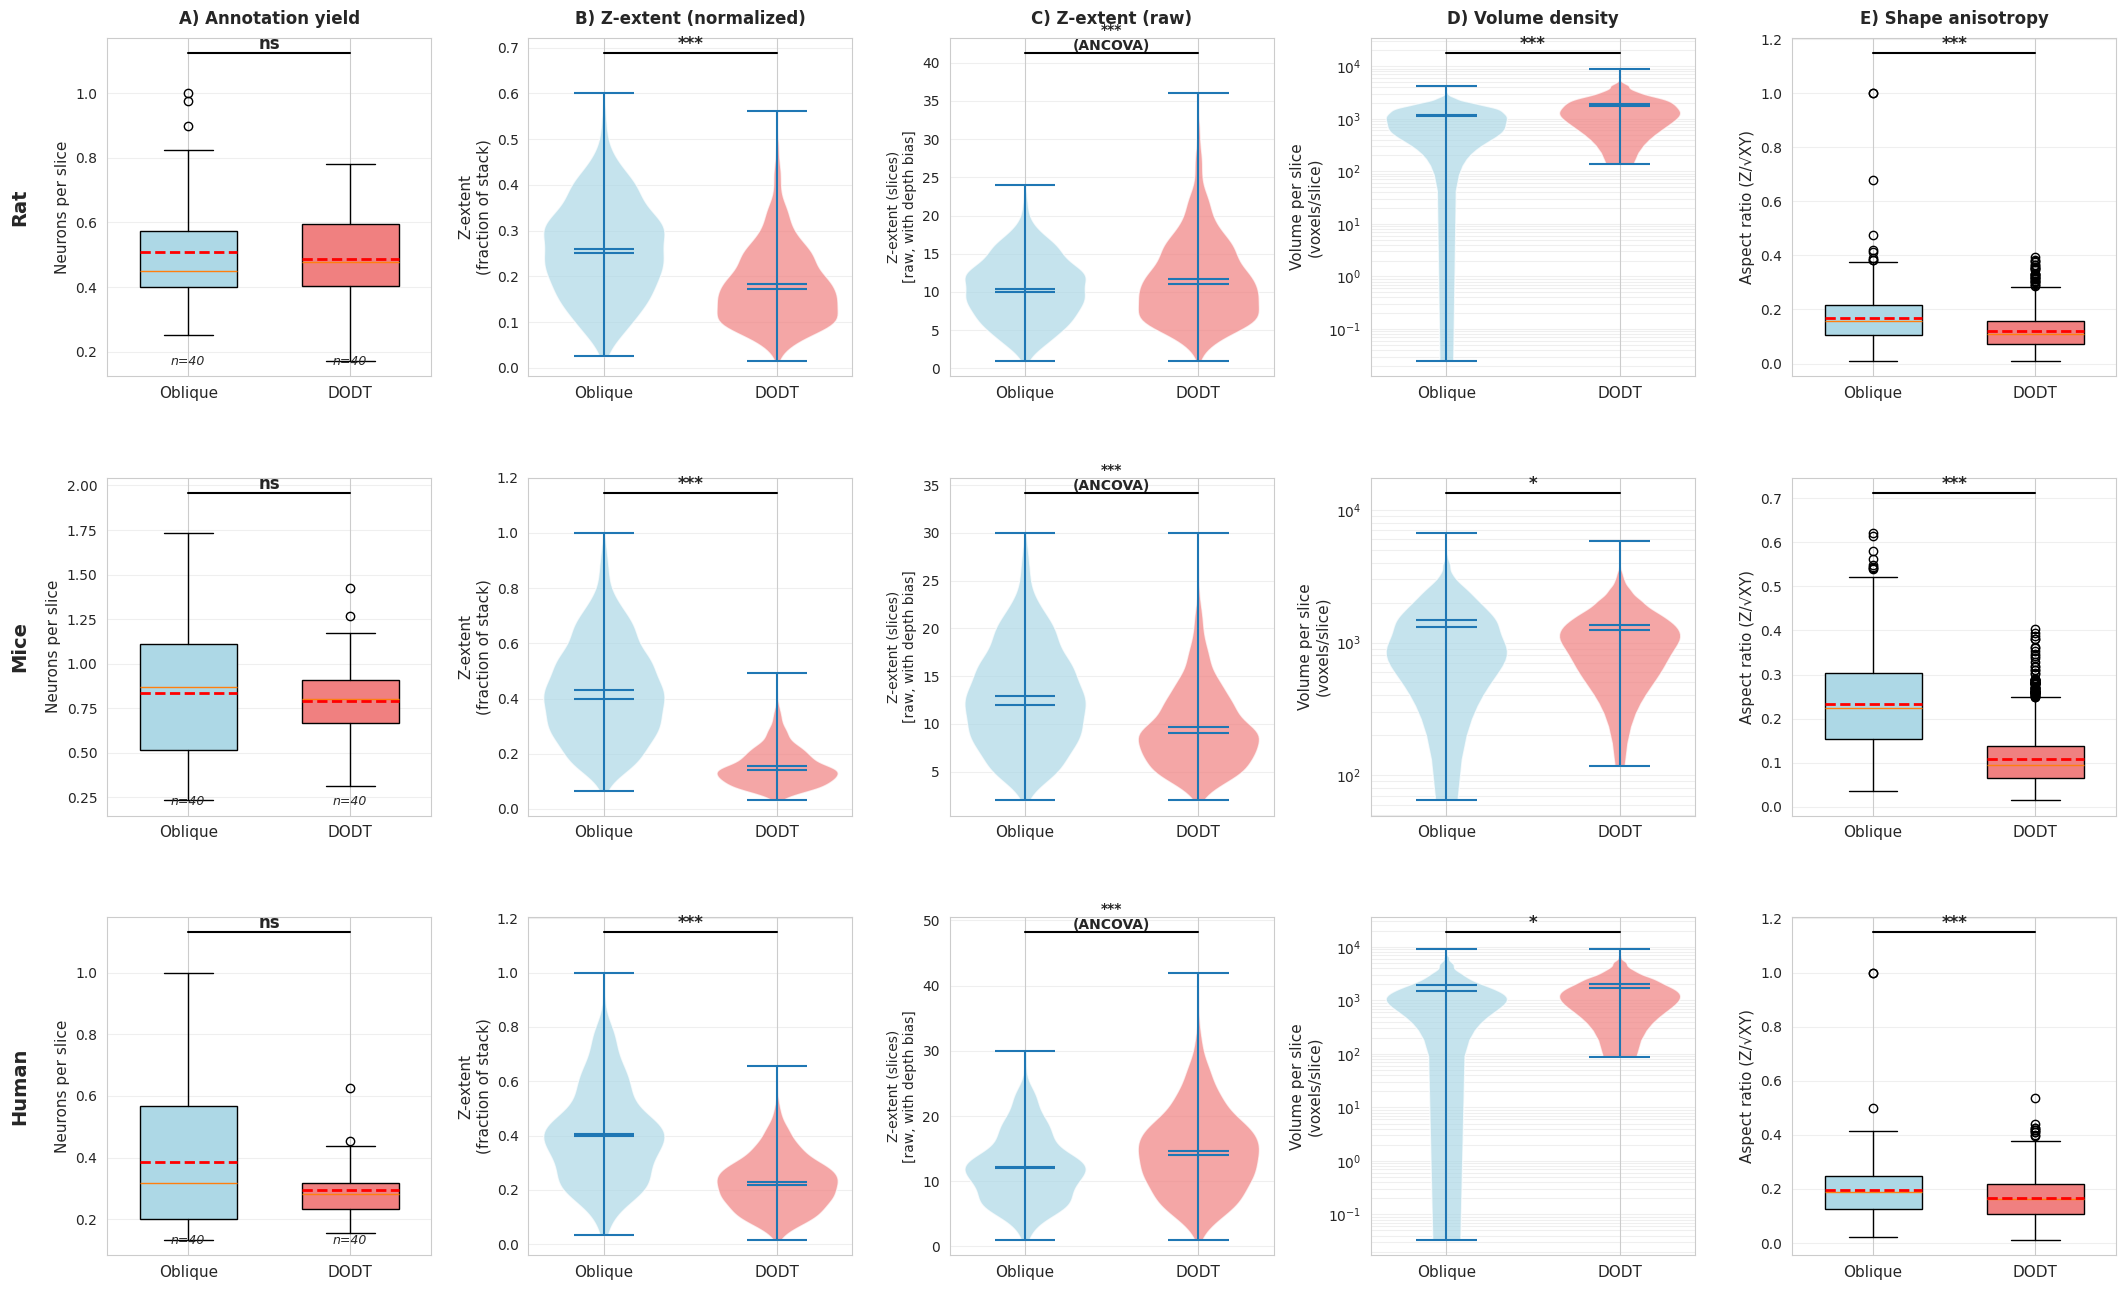


STATISTICAL SUMMARY WITH ANCOVA

Significance: * p<0.05, ** p<0.01, *** p<0.001, ns = not significant

Tests used:
  - Mann-Whitney U: for normalized metrics (neurons/slice, z-extent norm, volume/slice)
  - ANCOVA: for raw metrics with stack depth as covariate (z-extent raw)
  - Statistical tests only run when BOTH oblique and DODT data available


RAT:
----------------------------------------------------------------------
Available: Oblique (depth=40), DODT (depth=64)

Neurons per slice (per-file):
  Oblique: 0.509 ± 0.185 (median: 0.450, n=40 files)
  DODT:    0.488 ± 0.134 (median: 0.477, n=40 files)
  → Mann-Whitney U: p = 7.9485e-01 ns
  → Fold change (Oblique/DODT): 1.04×

Z-extent normalized (fraction of stack):
  Oblique: 0.259 ± 0.105 (median: 0.250, n=814 cells)
  DODT:    0.182 ± 0.087 (median: 0.172, n=1249 cells)
  → Mann-Whitney U: p = 9.0315e-63 ***

Z-extent raw (slices) [BIASED BY STACK DEPTH]:
  Oblique: 10.4 ± 4.2 (median: 10.0)
  DODT:    11.7 ± 5.6 (median: 11.0)


In [36]:
 # Generate publication figures
if stats_data is not None:
    create_publication_figures(stats_data, save_prefix='neuron_statistics')

## Example with Custom Folder Names

In [19]:
# If mask folders have different names
# stats_data = collect_statistics(root_directory, mask_folders=['annotations', 'labels', 'gt'],
#                                  z_step_um=1.0, volume_threshold=100)

In [45]:
# from pathlib import Path
# import numpy as np
# import tifffile
# def move_slice_in_tiff(
#     in_tif,
#     out_tif,
#     src=0,
#     dst=15,
# ):
#     """
#     Перемещает slice src на позицию dst в 3D TIFF (Z,Y,X)
#     Без изменения dtype, без изменения данных
#     """
#     in_tif = Path(in_tif)
#     out_tif = Path(out_tif)
#
#     vol = tifffile.imread(in_tif)
#
#     if vol.ndim != 3:
#         raise ValueError(f"Ожидался 3D TIFF (Z,Y,X), получено {vol.shape}")
#
#     z = vol.shape[0]
#     if not (0 <= src < z and 0 <= dst < z):
#         raise IndexError("src или dst вне диапазона")
#
#     order = list(range(z))
#     idx = order.pop(src)
#     order.insert(dst, idx)
#
#     vol_new = vol[order]
#
#     tifffile.imwrite(
#         out_tif,
#         vol_new
#         # compression не задаём — поведение как обычное сохранение
#     )
#
#     print(
#         f"{in_tif.name}: slice {src} → {dst} | "
#         f"shape {vol.shape} | dtype {vol.dtype}"
#     )

In [51]:
# move_slice_in_tiff(
#      "/NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/masks/mouse_obl_8.tif",
#      "/NAS/mmaiurov/datasets_benchmark/mice_neurons_oblique/masks/mouse_obl_8_.tif",
#      src=0,
#      dst=12
#  )

mouse_obl_8.tif: slice 0 → 12 | shape (30, 960, 1280) | dtype uint32
